# Experiment 2: Multiple, Lasso, and Ridge Regression\n\n**Dataset:** `insurance.csv`\n**Goal:** Predict medical `expenses` using all features and compare regularization techniques.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and explore the dataset
df = pd.read_csv('insurance.csv')
print("Shape:", df.shape)
print("\nDataset Info:")
print(df.describe())
print("\nMissing values:", df.isnull().sum().sum())
df.head()

Shape: (1338, 7)

Dataset Info:
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000  16639.915000
max      64.000000    53.100000     5.000000  63770.430000

Missing values: 0


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


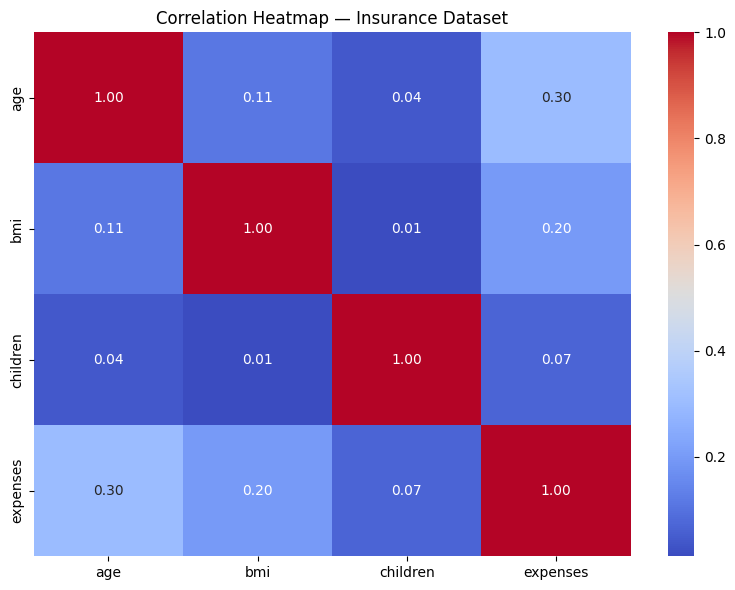

In [3]:
# Correlation Heatmap (numeric features only)
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — Insurance Dataset')
plt.tight_layout()
plt.show()

In [4]:
# Data Preprocessing
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Features & Target
X = df_encoded.drop('expenses', axis=1)
y = df_encoded['expenses']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size    :", X_test_scaled.shape)
print("\nFeatures used:", list(X.columns))

Training set size: (1070, 8)
Test set size    : (268, 8)

Features used: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


## Model 1: Multiple Linear Regression

In [5]:
# Multiple Linear Regression
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_test_scaled)

mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

print("=== Multiple Linear Regression ===")
print(f"Mean Squared Error : {mse_mlr:.2f}")
print(f"R2 Score           : {r2_mlr:.4f}")

=== Multiple Linear Regression ===
Mean Squared Error : 33600065.36
R2 Score           : 0.7836


## Model 2: Lasso Regression (L1 Regularization)

In [6]:
# Lasso Regression (L1)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("=== Lasso Regression (alpha=0.1) ===")
print(f"Mean Squared Error : {mse_lasso:.2f}")
print(f"R2 Score           : {r2_lasso:.4f}")

# Show which coefficients Lasso reduced to zero
feature_names = list(X.columns)
lasso_coeffs = pd.Series(lasso.coef_, index=feature_names)
print(f"\nCoefficients reduced to zero: {(lasso_coeffs == 0).sum()}")
print("\nLasso Coefficients:")
print(lasso_coeffs)

=== Lasso Regression (alpha=0.1) ===
Mean Squared Error : 33600486.25
R2 Score           : 0.7836

Coefficients reduced to zero: 0

Lasso Coefficients:
age                 3614.610608
bmi                 2037.119826
children             517.234528
sex_male              -9.144034
smoker_yes          9558.041695
region_northwest    -157.680644
region_southeast    -290.178359
region_southwest    -348.545100
dtype: float64


## Model 3: Ridge Regression (L2 Regularization)

In [7]:
# Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("=== Ridge Regression (alpha=1.0) ===")
print(f"Mean Squared Error : {mse_ridge:.2f}")
print(f"R2 Score           : {r2_ridge:.4f}")

=== Ridge Regression (alpha=1.0) ===
Mean Squared Error : 33608105.86
R2 Score           : 0.7835


## Model Comparison

In [8]:
# Comparison Table
results = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'Lasso (L1, alpha=0.1)', 'Ridge (L2, alpha=1.0)'],
    'MSE': [mse_mlr, mse_lasso, mse_ridge],
    'R2 Score': [r2_mlr, r2_lasso, r2_ridge]
})
print("=== Model Comparison ===")
results

=== Model Comparison ===


,Model,MSE,R2 Score
0,Multiple Linear Regression,3.360007e+07,0.783573
1,"Lasso (L1, alpha=0.1)",3.360049e+07,0.783570
2,"Ridge (L2, alpha=1.0)",3.360811e+07,0.783521


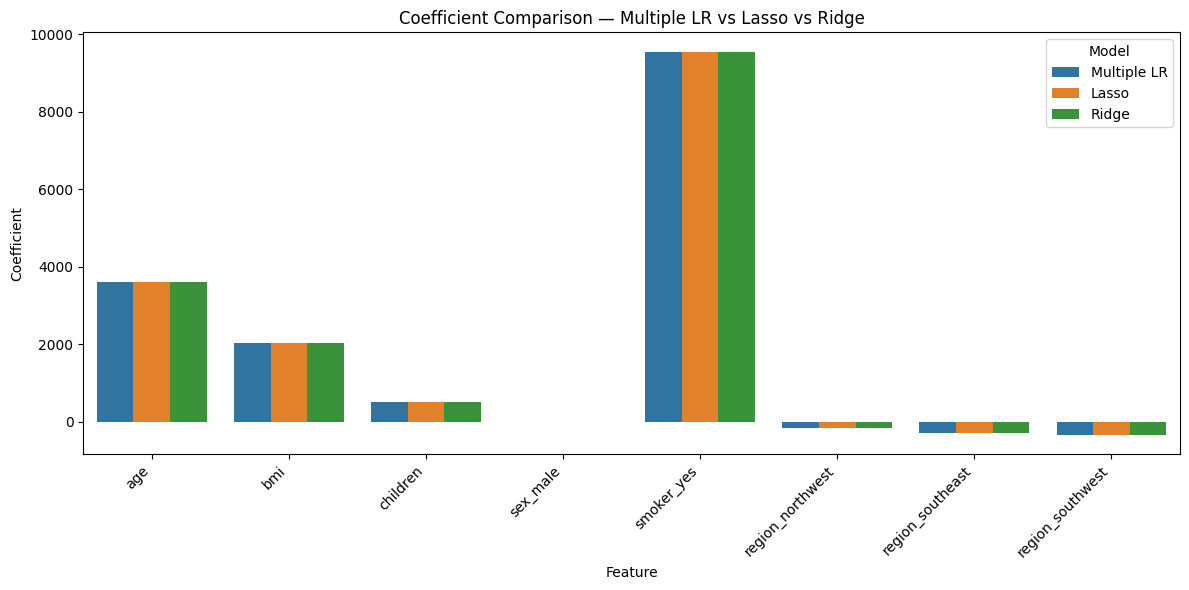

In [9]:
# Coefficient Comparison Plot
coeffs = pd.DataFrame({
    'Feature': feature_names,
    'Multiple LR': mlr.coef_,
    'Lasso': lasso.coef_,
    'Ridge': ridge.coef_
})

coeffs_melted = coeffs.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(data=coeffs_melted, x='Feature', y='Coefficient', hue='Model')
plt.xticks(rotation=45, ha='right')
plt.title('Coefficient Comparison — Multiple LR vs Lasso vs Ridge')
plt.tight_layout()
plt.show()